# VOCSegmentation (torchvision) + mały trening na GPU

Toy notebook do segmentacji: używa `torchvision.datasets.VOCSegmentation` (multi-class semantic segmentation) i trenuje mały U-Net na GPU (jeśli dostępny).

Maski VOC są per-piksel w zakresie klas `0..20` oraz mogą zawierać `255` jako `ignore_index`.

## 📝 Wielkie Zadanie: Budowa i Uruchomienie Sieci U-Net

**Zasoby i Dokumentacja:**
* Architektura referencyjna: [Pytorch-UNet na GitHub](https://github.com/milesial/pytorch-unet)
* Dokumentacja PyTorch: [Warstwy Konwolucyjne](https://pytorch.org/docs/stable/nn.html#convolution-layers)

### 🎯 Cel Edukacyjny
Celem nie jest uzyskanie idealnego modelu (segmentacja VOC jest trudna!), ale **zrozumienie przepływu danych w architekturze typu Encoder-Decoder** oraz poprawne połączenie warstw tak, aby proces uczenia w ogóle wystartował i zaczął generować sensowne maski.

### 🛠️ Twoje Zadania (Krok po Kroku):
1.  **Zdefiniowanie Bloku Konwolucyjnego (`ConvBlock`):** Uzupełnij warstwy tak, aby każdy blok składał się z dwóch operacji splotu (3x3), normalizacji batcha i aktywacji ReLU. Pamiętaj o zachowaniu wymiarów przestrzennych (padding!).
2.  **Konstrukcja Sieci (`SmallUNet`):** Dobierz liczby kanałów wejściowych i wyjściowych w konstruktorze `__init__`. Pamiętaj, że w dekoderze (po operacji `up`) łączysz cechy z enkodera, więc liczba kanałów wejściowych do `dec2` i `dec1` musi być sumą kanałów z 'dołu' i 'z boku' (skip-connection).
3.  **Dobór Hiperparametrów (`CONFIG`):**
    *   Zwiększ `epochs` (np. 10-20), aby model miał czas na naukę.
    *   Ustaw `max_steps_per_epoch` na `None`, by przejść przez cały zbiór.
    *   Eksperymentuj z parametrem `base` (np. 16, 32, 64) – im większy, tym model potężniejszy, ale wolniejszy.
4.  **Uruchomienie Treningu:** Sprawdź, czy `pixel_accuracy` rośnie, a funkcja kosztu maleje.

### ✅ Kryterium Sukcesu
Zadanie uznaje się za zaliczone, jeśli:
*   Kod modelu kompiluje się i wykonuje bez błędów wymiarów (*shape mismatch*).
*   Model zostanie wytrenowany przez co najmniej kilka epok.
*   Wizualizacja na końcu notebooka pokazuje, że model **próbuje** segmentować obiekty (nawet jeśli kontury są jeszcze nieprecyzyjne).

In [2]:
import random

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


## CONFIG

In [3]:
# ZADANIE: Dobierz parametry tak, aby uzyskać satysfakcjonujące wyniki segmentacji.
CONFIG = {
    "data_root": "./data_voc",
    "image_size": 128,
    "batch_size": 8,
    "num_workers": 2,

    "num_classes": 21,
    "ignore_index": 255,

    "lr": 1e-3,
    "epochs": 50,           # Zwiększ liczbę epok
    "max_steps_per_epoch": None, # Ustaw None, aby trenować na pełnym zbiorze
}

print(CONFIG)

{'data_root': './data_voc', 'image_size': 128, 'batch_size': 8, 'num_workers': 2, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.001, 'epochs': 50, 'max_steps_per_epoch': None}


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size):
        self.voc = voc_dataset
        self.image_size = image_size

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]  # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()  # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"])
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"])

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])


100%|██████████| 2.00G/2.00G [01:30<00:00, 22.1MB/s]


img_t: torch.Size([3, 128, 128]) mask_t: torch.Size([128, 128])
mask unique sample: tensor([  0,   1,  15, 255])


### Podgląd danych wejściowych (VOC)
Wyświetlamy kilka przykładowych obrazów ze zbioru treningowego wraz z ich maskami segmentacji.

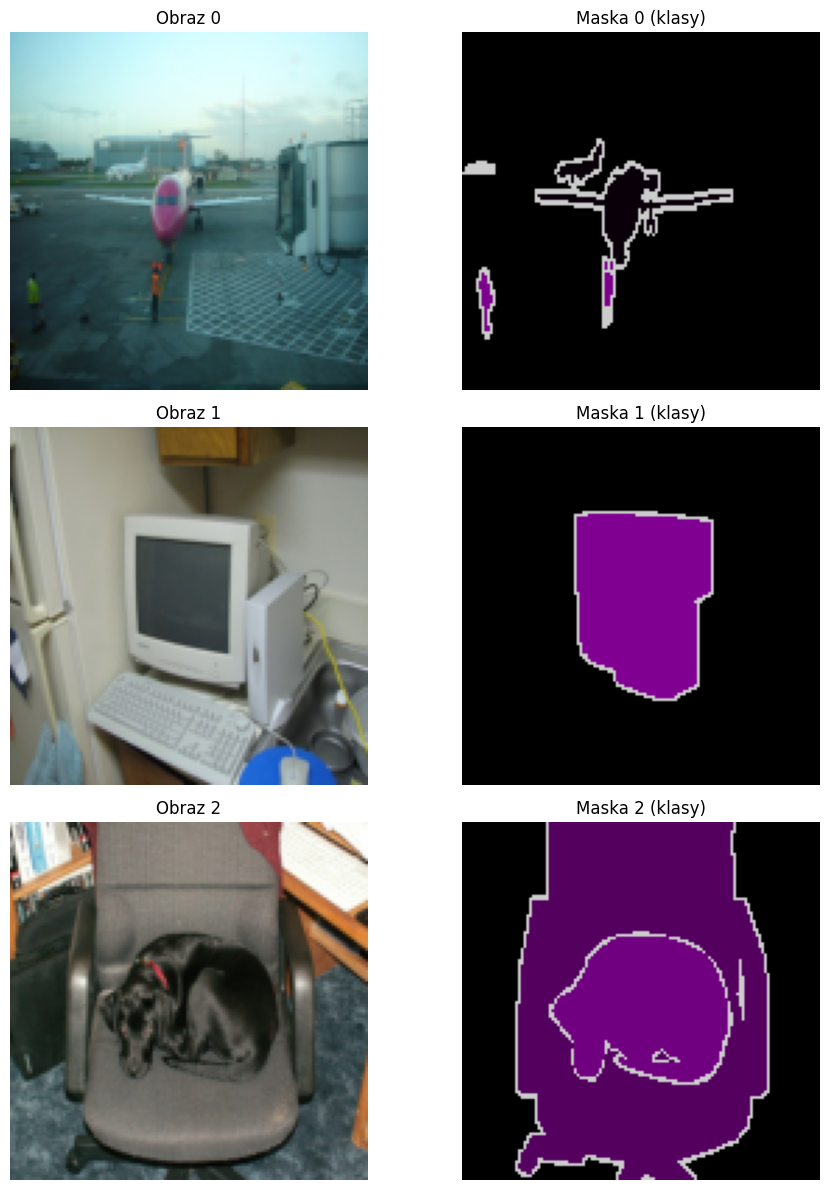

In [5]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # Maska (mapujemy 255 na 0 dla lepszej widoczności lub zostawiamy jako raw)
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)

In [6]:
import torch.nn as nn
import torch

class ConvBlock(nn.Module):
    """
    ZADANIE: Zaimplementuj blok: [Conv 3x3, BN, ReLU] x 2.
    Pamiętaj o padding=1, aby nie zmniejszać wymiarów obrazu.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # TODO: Zdefiniuj self.net jako nn.Sequential z odpowiednimi warstwami
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

class SmallUNet(nn.Module):
    """
    ZADANIE: Zdefiniuj warstwy encodera, bottlenecku i decodera w __init__.
    Dobierz kanały tak, aby pasowały do logiki konkatenacji w forward.
    """
    def __init__(self, in_channels=3, base=16, num_classes=21):
        super().__init__()
        # --- Encoder ---
        # TODO: zdefiniuj self.enc1, self.pool1, self.enc2, self.pool2
        self.enc1 = ConvBlock(in_ch=in_channels, out_ch=base,)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = ConvBlock(in_ch=base, out_ch=base*2,)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Bottleneck ---
        # TODO: zdefiniuj self.bottleneck

        self.bottleneck = ConvBlock(in_ch=base*2, out_ch=base*4)

        # --- Decoder ---
        # TODO: zdefiniuj self.up2, self.dec2, self.up1, self.dec1
        # Wskazówka: self.dec2 przyjmuje kanały z (up2 + enc2)

        self.up2 = nn.ConvTranspose2d(in_channels=base*4, out_channels=base*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(in_ch=base*4, out_ch=base*2)

        self.up1 = nn.ConvTranspose2d(in_channels=base*2, out_channels=base, kernel_size=2, stride=2)
        self.dec1 =  ConvBlock(in_ch=base*2, out_ch=base)
        # --- Output ---
        # TODO: zdefiniuj self.final (Conv 1x1)
        self.final = nn.Conv2d(in_channels=base, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
        # --- Encoder ---
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # --- Bottleneck ---
        b = self.bottleneck(p2)

        # --- Decoder ze Skip-Connections ---
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

# Inicjalizacja modelu - studenci mogą tu zmieniać parametr 'base'
model = SmallUNet(base=32).to(device)

In [7]:
criterion = nn.CrossEntropyLoss(ignore_index=CONFIG["ignore_index"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()


best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running = 0.0
    steps = 0

    for step, (imgs, masks) in enumerate(train_loader):
        #Dopisałem tutaj żeby sprawdzało czy nie jest None bo wywalało błąd "'>=' not supported between instances of 'int' and 'NoneType'"
        if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
            break
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        steps += 1

    model.eval()
    accs = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            accs.append(pixel_accuracy(logits, masks))

    val_acc = float(np.mean(accs))
    train_loss = running / max(1, steps)
    best_val_acc = max(best_val_acc, val_acc)

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_acc:.4f}")

print("best_val_acc:", best_val_acc)


Epoch 1/50 | train_loss=1.6586 | val_pixel_acc=0.7251
Epoch 2/50 | train_loss=1.2340 | val_pixel_acc=0.7303
Epoch 3/50 | train_loss=1.2106 | val_pixel_acc=0.7296
Epoch 4/50 | train_loss=1.1988 | val_pixel_acc=0.7315
Epoch 5/50 | train_loss=1.1757 | val_pixel_acc=0.7312
Epoch 6/50 | train_loss=1.1610 | val_pixel_acc=0.7321
Epoch 7/50 | train_loss=1.1463 | val_pixel_acc=0.7305
Epoch 8/50 | train_loss=1.1298 | val_pixel_acc=0.7325
Epoch 9/50 | train_loss=1.1151 | val_pixel_acc=0.7343
Epoch 10/50 | train_loss=1.0990 | val_pixel_acc=0.7336
Epoch 11/50 | train_loss=1.0919 | val_pixel_acc=0.7330
Epoch 12/50 | train_loss=1.0834 | val_pixel_acc=0.7341
Epoch 13/50 | train_loss=1.0764 | val_pixel_acc=0.7335
Epoch 14/50 | train_loss=1.0642 | val_pixel_acc=0.7360
Epoch 15/50 | train_loss=1.0551 | val_pixel_acc=0.7360
Epoch 16/50 | train_loss=1.0511 | val_pixel_acc=0.7316
Epoch 17/50 | train_loss=1.0399 | val_pixel_acc=0.7338
Epoch 18/50 | train_loss=1.0267 | val_pixel_acc=0.7386
Epoch 19/50 | train

### Wizualizacja wyników treningu
Nakładamy przewidziane maski na obrazy walidacyjne oraz wyświetlamy legendę klas VOC.

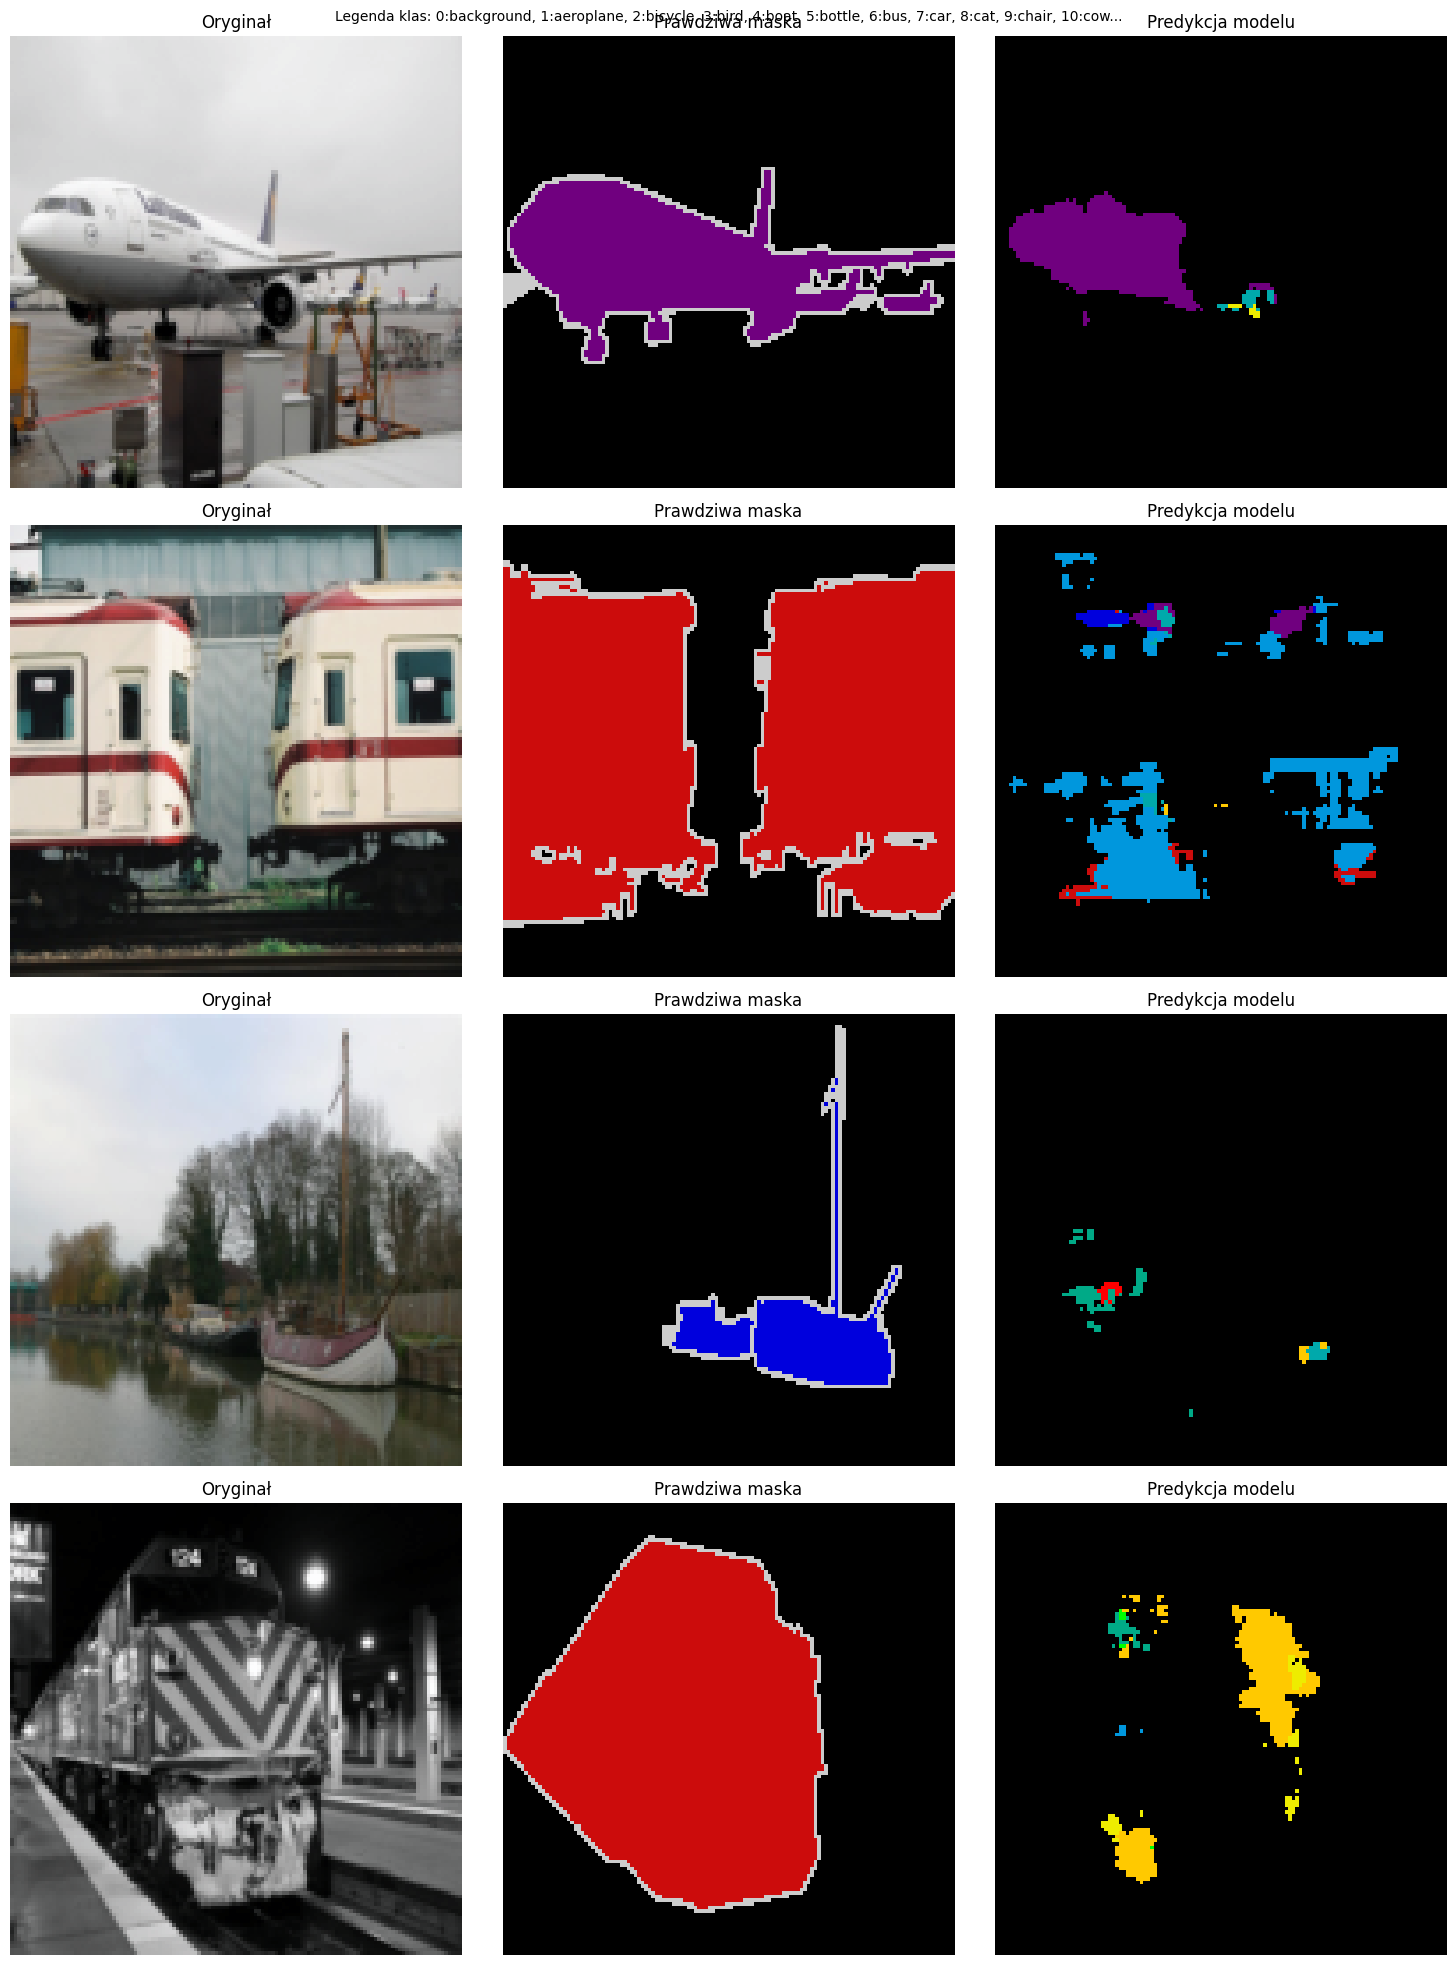

In [8]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    #Z jakiegoś powodu wizualizacja nie działa i predykcja modelu zwraca pusty obraz pomimo val_pixel_axx =~ 0.7
    # Dobra nieważne XD
    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, device)

# Historia uczenia
wypełniłem wszystko model ruszył i miał wydawałoby sie dobre wyniki:
- Epoch 1/5 | train_loss=1.6602 | val_pixel_acc=0.7216
- Epoch 2/5 | train_loss=1.2389 | val_pixel_acc=0.7302
- Epoch 3/5 | train_loss=1.2123 | val_pixel_acc=0.7295
- Epoch 4/5 | train_loss=1.2027 | val_pixel_acc=0.7306
- Epoch 5/5 | train_loss=1.1731 | val_pixel_acc=0.7308
- best_val_acc: 0.7307538146173561

Okazało się jednak że model nie wyświetla maski dlaczego?
Ponieważ postanowił za każdym razem wybierać kolor tła czyli czarny co skutkowało "dobrymi" wynikami bez konieczności faktycznej predykcji.

Żeby to naprawić zwiekszyłem liczbe epok do 40 .
Teraz model może nie jest idealny ale działa

Postanowiłem równiesz się pobawic i zmniejszyć batch_size do 4(troche żeby szybciej uczenie szło ale też żeby zobaczyć), oraz zwiększyłem learnig rate 5 krotnie(gdyż widziałem że zmiany zachodziły bardzo powoli)

Potem dotrenowałem ten sam model (odpalając ponownie tą samą komórke odpowiedzialna za trening bez reinicjalizacji) na mniejszym training rate jednak wyniki były mniej satysfakcjonujące niż dla base=32 i liczby epok=40

Postanowiłem więc sprawdzić jak model zareaguje na base=16
Jednak ten model również nie generował zadowalających wyników

dlatego ostatecznie zostawiam model:
- base = 32
- liczba epok = 50
- lr = 1e-3
- batch size = 8

# Eksperyment
a co jeżeli zrobilibyśmy trening gdzie learning rate zmieniałby się dynamicznie(tzn. zmniejszał się 2x krotnie co 20 epok)?

Wstępne parametry modelu:
- base = 64 (jest dużo epok więc licze że zwiekszenie złożoności pomoże)
- liczba epok = 100
- lr = 4e-3
- batch size = 8

In [9]:
#reinicjalizacja modelu
model = SmallUNet(base=64).to(device)

#zmiana parametrów
CONFIG["epochs"] = 100
CONFIG["lr"] = 4e-3

#trening z dynamicna zmiana lr
criterion = nn.CrossEntropyLoss(ignore_index=CONFIG["ignore_index"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

#sheduler do zmiany lr*0.5 co 10 epok
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()


best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running = 0.0
    steps = 0

    for step, (imgs, masks) in enumerate(train_loader):
        #Dopisałem tutaj żeby sprawdzało czy nie jest None bo wywalało błąd "'>=' not supported between instances of 'int' and 'NoneType'"
        if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
            break
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        steps += 1

    model.eval()
    accs = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            accs.append(pixel_accuracy(logits, masks))

    val_acc = float(np.mean(accs))
    train_loss = running / max(1, steps)
    best_val_acc = max(best_val_acc, val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} | LR: {current_lr:.6f} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f}")
    scheduler.step()
print("best_val_acc:", best_val_acc)


Epoch 1 | LR: 0.004000 | train_loss=1.3447 | val_acc=0.7306
Epoch 2 | LR: 0.004000 | train_loss=1.2452 | val_acc=0.7299
Epoch 3 | LR: 0.004000 | train_loss=1.2349 | val_acc=0.7306
Epoch 4 | LR: 0.004000 | train_loss=1.2285 | val_acc=0.7296
Epoch 5 | LR: 0.004000 | train_loss=1.2214 | val_acc=0.7304
Epoch 6 | LR: 0.004000 | train_loss=1.2144 | val_acc=0.7290
Epoch 7 | LR: 0.004000 | train_loss=1.1975 | val_acc=0.7306
Epoch 8 | LR: 0.004000 | train_loss=1.1909 | val_acc=0.7299
Epoch 9 | LR: 0.004000 | train_loss=1.1734 | val_acc=0.7309
Epoch 10 | LR: 0.004000 | train_loss=1.1648 | val_acc=0.7334
Epoch 11 | LR: 0.004000 | train_loss=1.1546 | val_acc=0.7319
Epoch 12 | LR: 0.004000 | train_loss=1.1502 | val_acc=0.7309
Epoch 13 | LR: 0.004000 | train_loss=1.1406 | val_acc=0.7247
Epoch 14 | LR: 0.004000 | train_loss=1.1275 | val_acc=0.7341
Epoch 15 | LR: 0.004000 | train_loss=1.1202 | val_acc=0.7340
Epoch 16 | LR: 0.004000 | train_loss=1.1112 | val_acc=0.7341
Epoch 17 | LR: 0.004000 | train_l

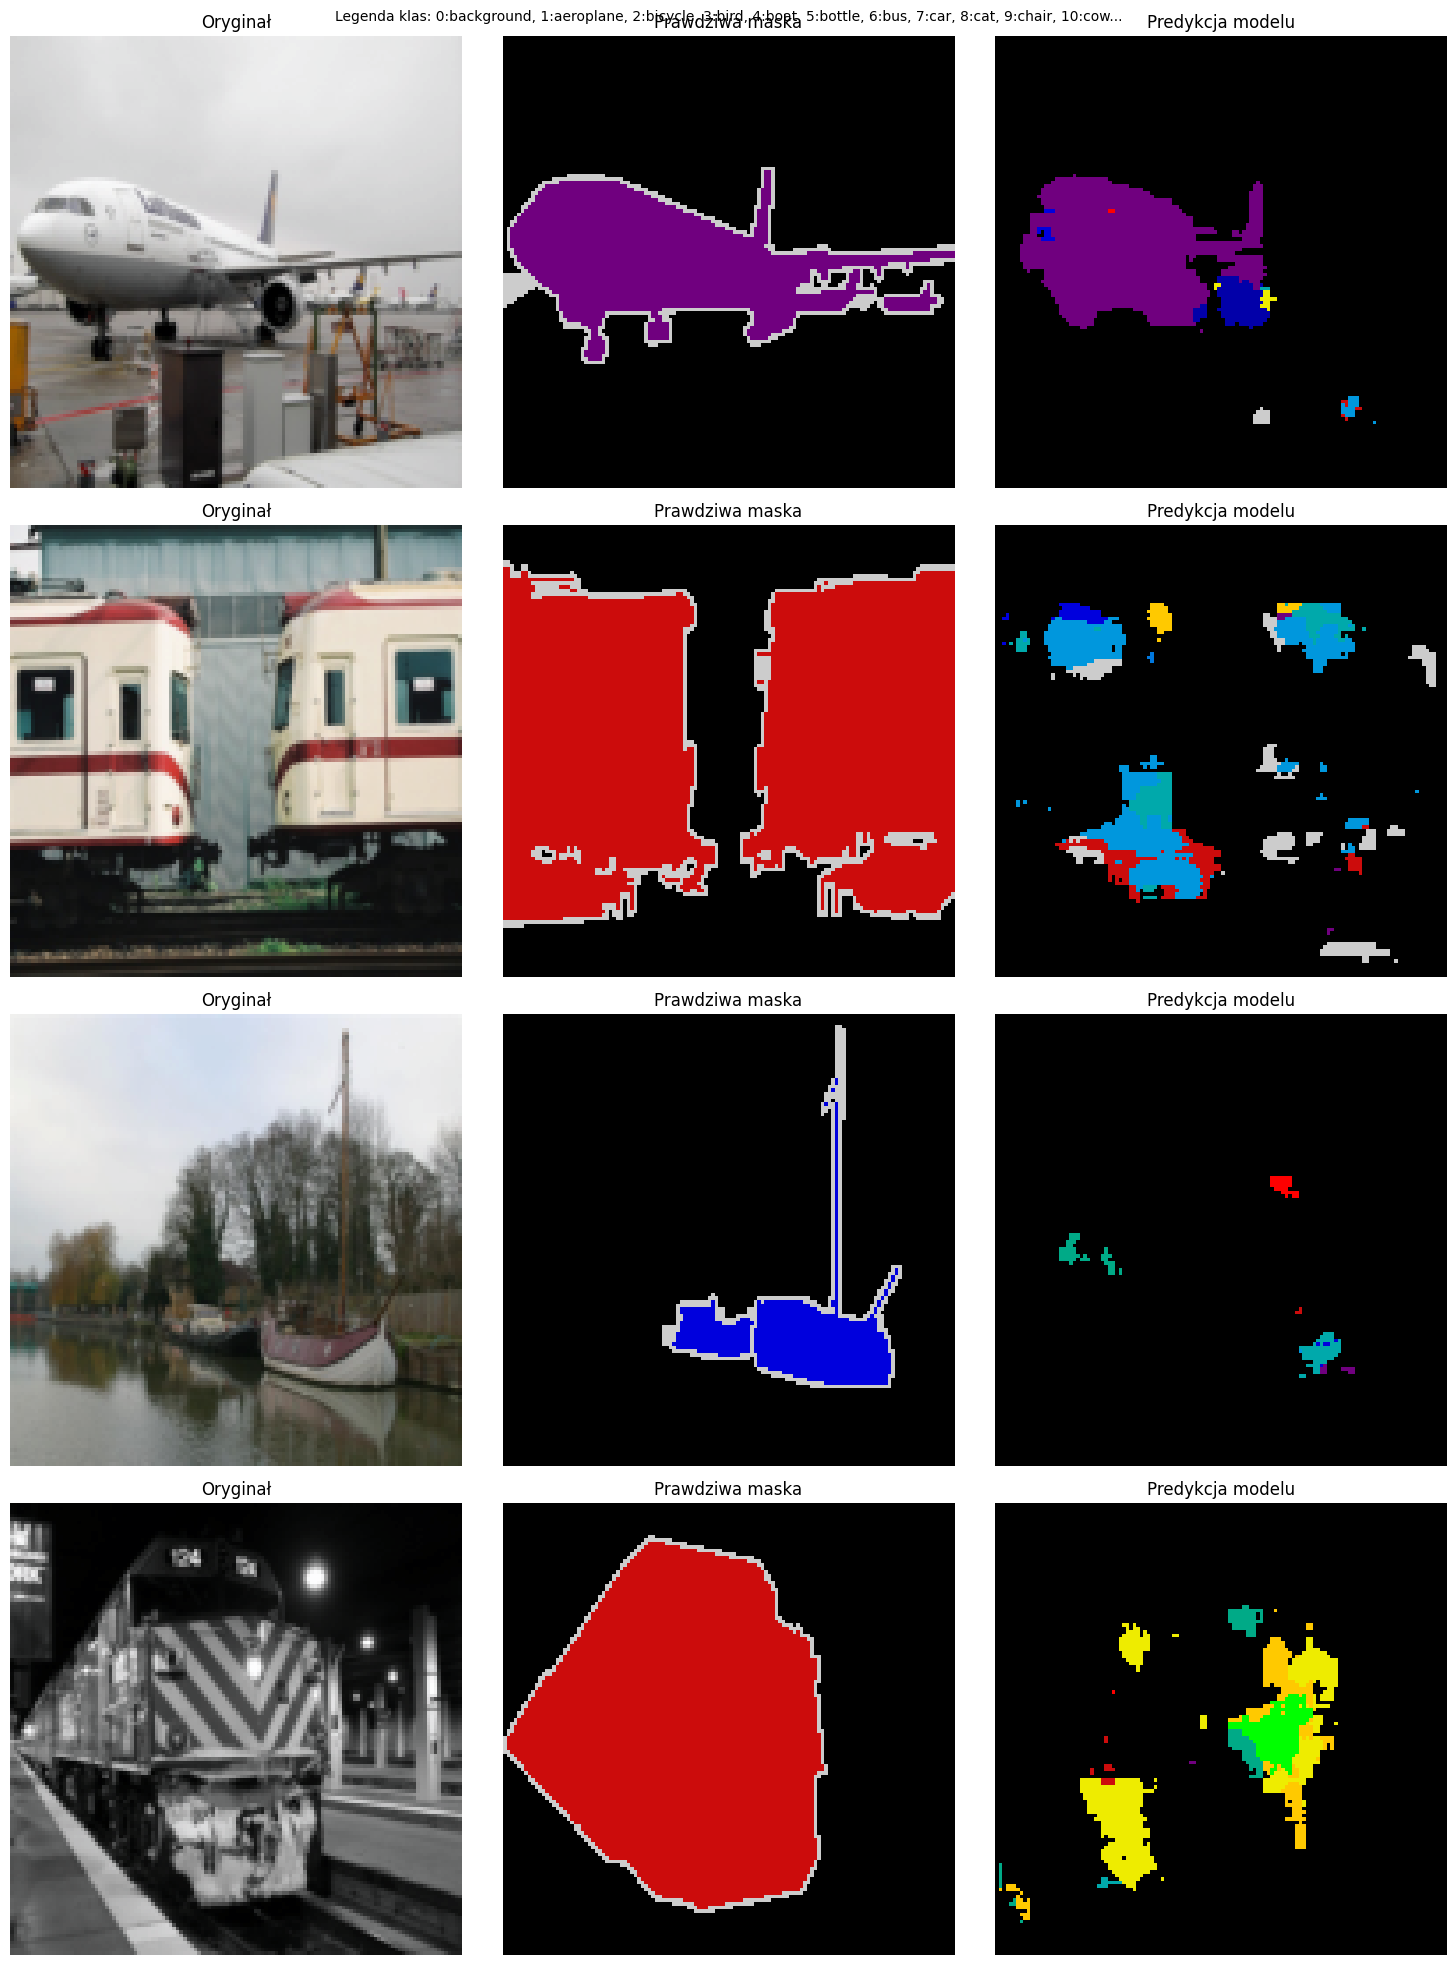

In [10]:
#wizualizacja dla alternatywnego treningu
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    #Z jakiegoś powodu wizualizacja nie działa i predykcja modelu zwraca pusty obraz pomimo val_pixel_axx =~ 0.7
    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]

            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, device)

Wyniki są bardziej zadowalające, pomimo że accuracy jest takie samo to widać że model bardziej próbuje robić maski a nie tylko przewidywać tło.


Spróbowałbym jeszcze zrobić dodatkową augmentacje żeby zobaczyć czy nie uda się przeskoczyć tych 0.75 w accuracy zwłąszcza że widzimy że val_acc stoi w miejscu pomimo że training_loss spada co może świadczyć o przetrenowaniu

In [11]:


CONFIG = {
    "data_root": "./data_voc",
    "image_size": 128,
    "batch_size": 8,
    "num_workers": 2,
    "num_classes": 21,
    "ignore_index": 255,
    "lr": 4e-3,
    "epochs": 100,
    "max_steps_per_epoch": None,
}




# DEFINICJA KLASY VOCResizeWrapper Z AUGMENTACJAMI

class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size, augment=False):
        self.voc = voc_dataset
        self.image_size = image_size
        self.augment = augment
        self.color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]

        # Resize (zawsze)
        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)


        if self.augment:
            # Flip poziomy (50% szans)
            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            # Obrót o losowy kąt (-10, 10) stopni (50% szans)
            if random.random() > 0.5:
                angle = random.uniform(-10, 10)
                img = TF.rotate(img, angle, interpolation=Image.BILINEAR)
                mask = TF.rotate(mask, angle, interpolation=Image.NEAREST)

            # Zmiana kolorów (tylko obraz)
            img = self.color_jitter(img)


        # Konwersja na tensor
        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()
        return img_t, mask_t

#  Pobranie i stworzenie loaderów

train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)
val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"], augment=True)
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"], augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)


# Inicjalizacja modelu
model = SmallUNet(base=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

criterion = nn.CrossEntropyLoss(ignore_index=CONFIG["ignore_index"])


def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()


best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running = 0.0
    steps = 0

    for step, (imgs, masks) in enumerate(train_loader):
        if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
            break
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        steps += 1

    model.eval()
    accs = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            accs.append(pixel_accuracy(logits, masks))

    val_acc = float(np.mean(accs))
    train_loss = running / max(1, steps)
    best_val_acc = max(best_val_acc, val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} | LR: {current_lr:.6f} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f}")
    scheduler.step()

print("best_val_acc:", best_val_acc)

Epoch 1 | LR: 0.004000 | train_loss=1.3647 | val_acc=0.7291
Epoch 2 | LR: 0.004000 | train_loss=1.2497 | val_acc=0.7294
Epoch 3 | LR: 0.004000 | train_loss=1.2443 | val_acc=0.7306
Epoch 4 | LR: 0.004000 | train_loss=1.2230 | val_acc=0.7305
Epoch 5 | LR: 0.004000 | train_loss=1.2084 | val_acc=0.6952
Epoch 6 | LR: 0.004000 | train_loss=1.1982 | val_acc=0.7314
Epoch 7 | LR: 0.004000 | train_loss=1.1874 | val_acc=0.7316
Epoch 8 | LR: 0.004000 | train_loss=1.1814 | val_acc=0.7300
Epoch 9 | LR: 0.004000 | train_loss=1.1735 | val_acc=0.7304
Epoch 10 | LR: 0.004000 | train_loss=1.1580 | val_acc=0.7306
Epoch 11 | LR: 0.004000 | train_loss=1.1524 | val_acc=0.7303
Epoch 12 | LR: 0.004000 | train_loss=1.1413 | val_acc=0.7314
Epoch 13 | LR: 0.004000 | train_loss=1.1245 | val_acc=0.7342
Epoch 14 | LR: 0.004000 | train_loss=1.1219 | val_acc=0.7260
Epoch 15 | LR: 0.004000 | train_loss=1.1098 | val_acc=0.7326
Epoch 16 | LR: 0.004000 | train_loss=1.1030 | val_acc=0.7354
Epoch 17 | LR: 0.004000 | train_l

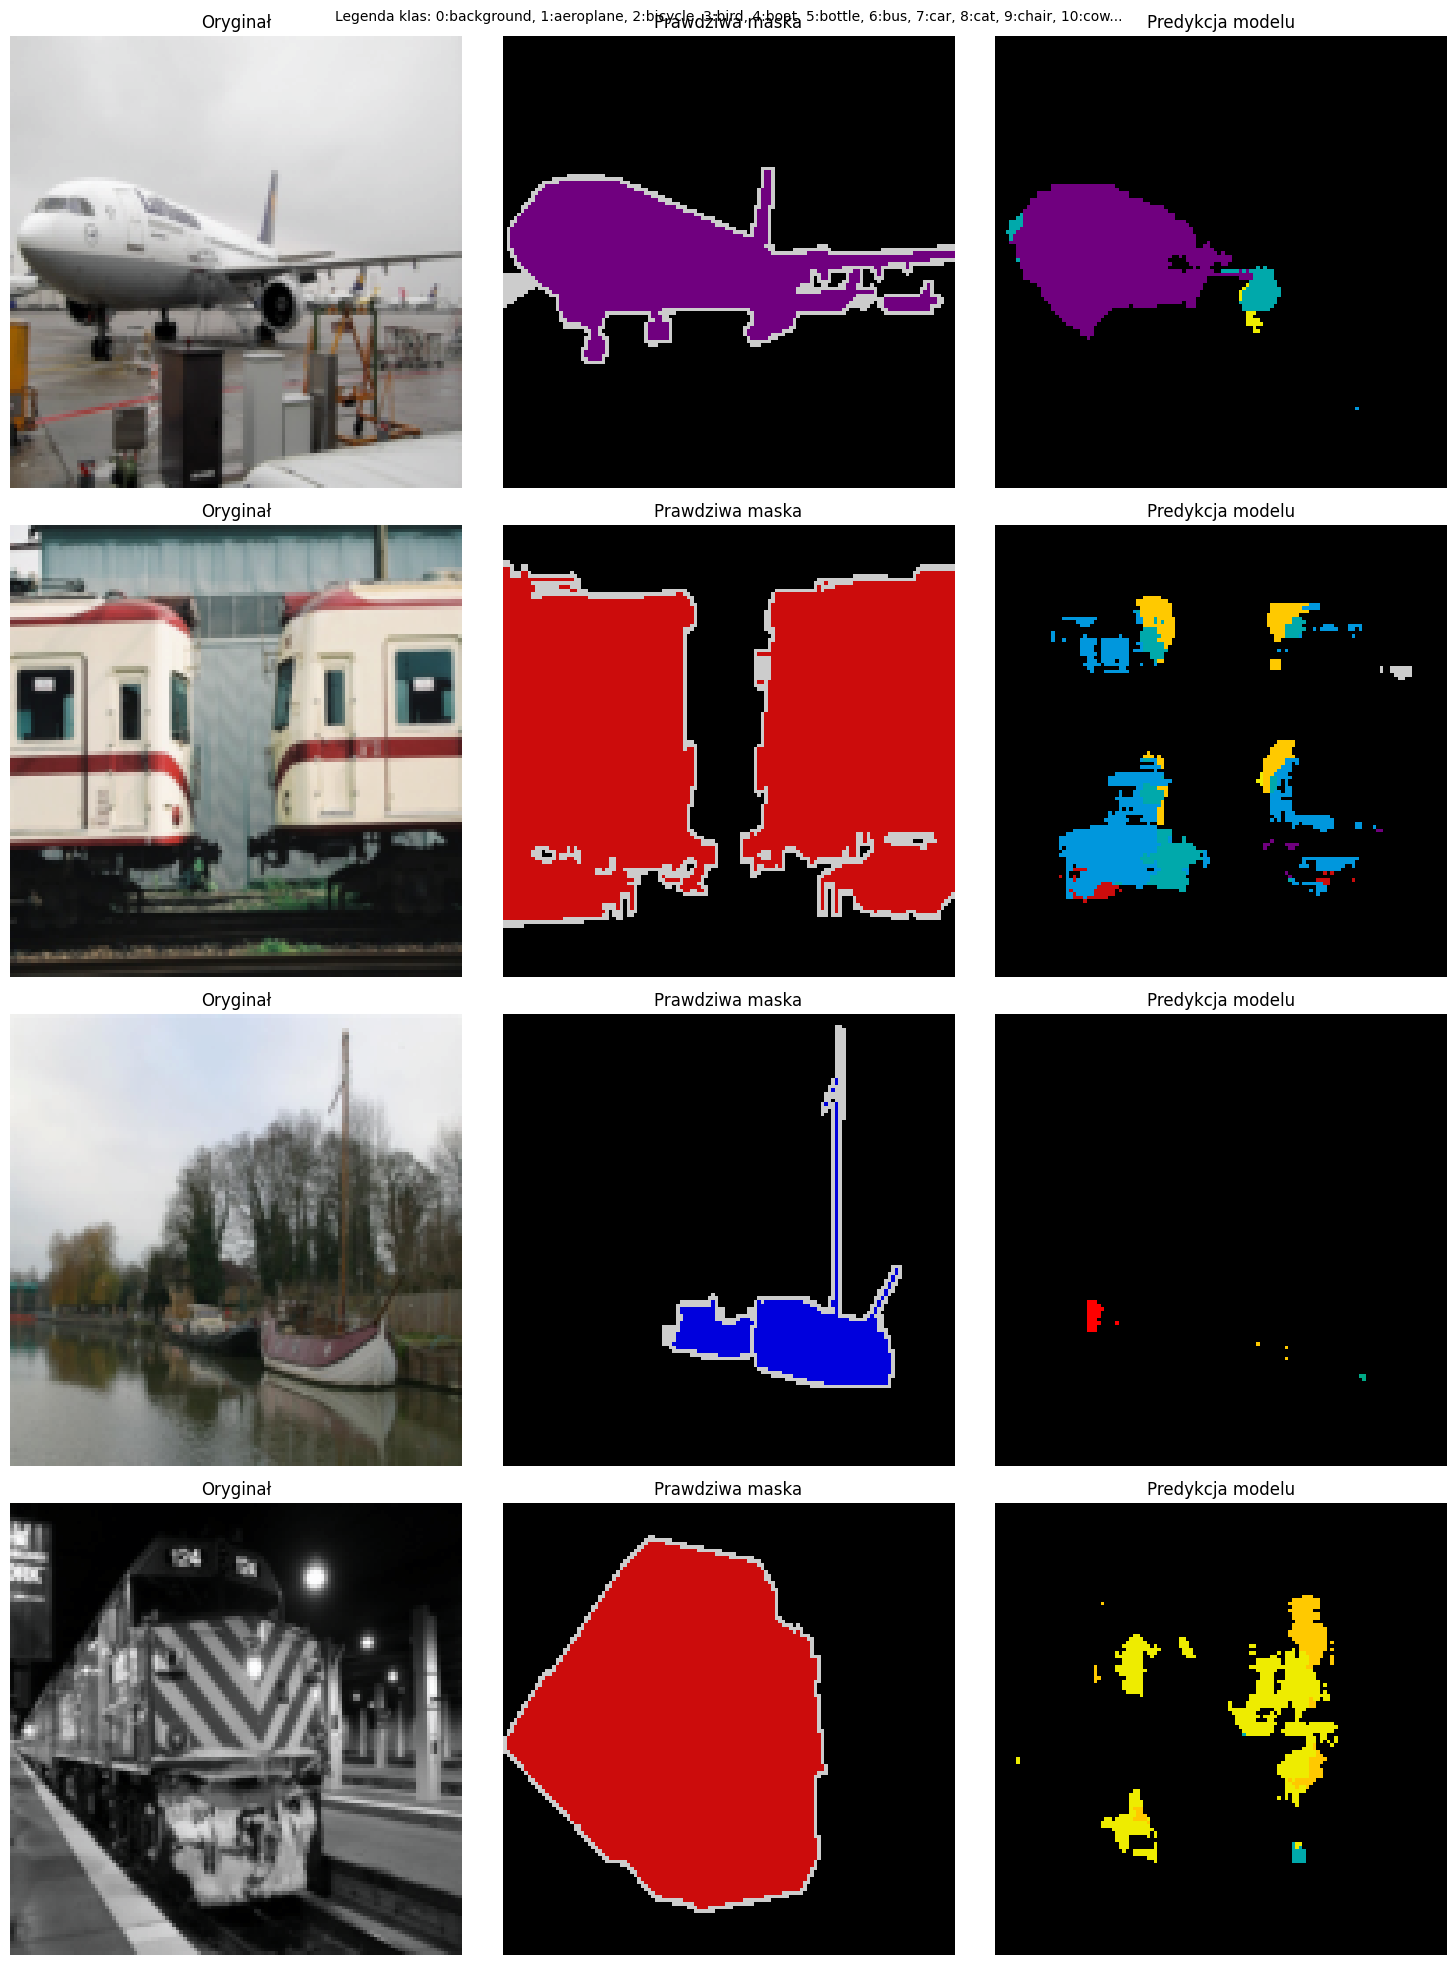

In [12]:
#wizualizacja dla alternatywnego treningu
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    #Z jakiegoś powodu wizualizacja nie działa i predykcja modelu zwraca pusty obraz pomimo val_pixel_axx =~ 0.7
    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]

            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, device)

# Wiem że nic niewiem

wyniki liczbowe są lepsze delikatnie lepsze ale maski niestety nie przypominają zbytnio oryginalnych :/